In [84]:
import warnings
warnings.filterwarnings("ignore")

In [85]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys

In [86]:
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.preprocessing import LabelEncoder

In [87]:
import STAGATE_pyG as STAGATE

In [88]:
# the location of R (used for the mclust clustering)
os.environ['R_HOME'] = '/usr/lib/R'
os.environ['R_USER'] = '/home/caizj/.local/lib/python3.10/site-packages/rpy2'

In [89]:
section_id = '151676'

In [90]:
input_dir = os.path.join('Data', section_id)
adata = sc.read_visium(path=input_dir, count_file=section_id+'_filtered_feature_bc_matrix.h5')
adata.var_names_make_unique()

In [91]:
adata

AnnData object with n_obs × n_vars = 3460 × 33538
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [92]:
#Normalization

# 数据预处理步骤：选择高变基因
# 使用 seurat_v3 方法选择 3000 个高变基因，这些基因在不同细胞或斑点间表达差异较大，对后续分析有重要意义
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
# 对数据进行归一化处理，将每个细胞或斑点的总表达量归一化到 1e4，便于不同细胞间表达量的比较
sc.pp.normalize_total(adata, target_sum=1e4)
# 对归一化后的数据进行对数转换，log1p 表示 log(1 + x)，可以减小数据的动态范围，使数据分布更符合分析要求
sc.pp.log1p(adata)

In [93]:
# 读取细胞或斑点的注释信息
# 使用 pandas 的 read_csv 函数读取注释文件，文件格式为制表符分隔，没有表头，第一列作为索引
Ann_df = pd.read_csv(os.path.join('Data', section_id, section_id+'_truth.txt'), sep='\t', header=None, index_col=0)
# 为注释数据框的列命名为 'Ground Truth'，表示真实的细胞类型标签
Ann_df.columns = ['Ground Truth']

In [94]:
# 将注释信息添加到 AnnData 对象的观测值元数据中，以便后续分析和可视化
adata.obs['Ground Truth'] = Ann_df.loc[adata.obs_names, 'Ground Truth']

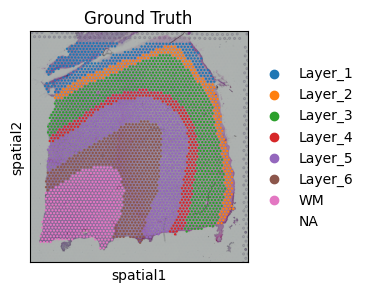

In [95]:
# 设置 matplotlib 绘图的默认图形大小为 3x3 英寸
plt.rcParams["figure.figsize"] = (3, 3)
# 使用 scanpy 的 spatial 绘图函数，在高分辨率图像上绘制细胞或斑点的真实细胞类型标签
sc.pl.spatial(adata, img_key="hires", color=["Ground Truth"])

Constructing the spatial network
构建空间网络图

------Calculating spatial graph...
The graph contains 20052 edges, 3460 cells.
5.7954 neighbors per cell on average.


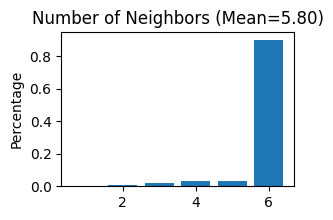

In [96]:
STAGATE.Cal_Spatial_Net(adata, rad_cutoff=150)
STAGATE.Stats_Spatial_Net(adata)

Running STAGATE
运行 STAGATE

In [97]:
adata = STAGATE.train_STAGATE(adata,n_epochs=1000)

Size of Input:  (3460, 3000)


100%|██████████| 1000/1000 [00:18<00:00, 54.60it/s]


In [98]:
sc.pp.neighbors(adata, use_rep='STAGATE')
sc.tl.umap(adata)
adata = STAGATE.mclust_R(adata, used_obsm='STAGATE', num_cluster=7)

fitting ...
  |======================================================================| 100%


In [99]:
obs_df = adata.obs.dropna()
ARI = adjusted_rand_score(obs_df['mclust'], obs_df['Ground Truth'])
print('Adjusted rand index = %.2f' %ARI)

Adjusted rand index = 0.35


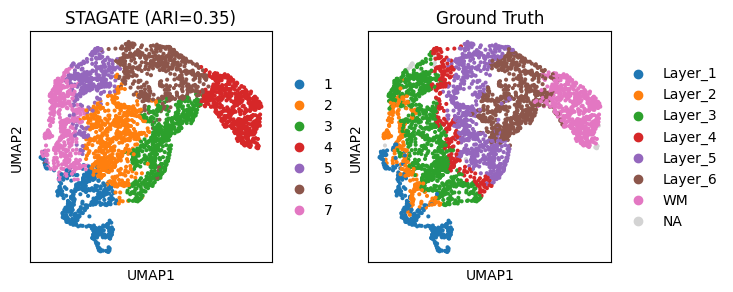

In [100]:
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.umap(adata, color=["mclust", "Ground Truth"], title=['STAGATE (ARI=%.2f)'%ARI, "Ground Truth"])

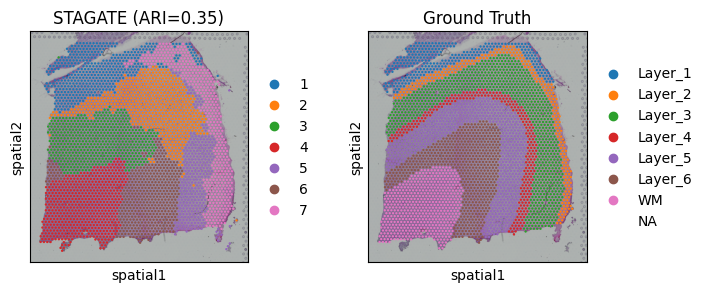

In [101]:
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.spatial(adata, color=["mclust", "Ground Truth"], title=['STAGATE (ARI=%.2f)'%ARI, "Ground Truth"])

Spatial trajectory inference (PAGA)
空间轨迹推断（PAGA）

In [108]:
used_adata = adata[~adata.obs['Ground Truth'].isna()].copy()
used_adata
# print(used_adata.obs['Ground Truth'].unique())

AnnData object with n_obs × n_vars = 3431 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'Ground Truth', 'mclust'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p', 'Ground Truth_colors', 'Spatial_Net', 'neighbors', 'umap', 'mclust_colors'
    obsm: 'spatial', 'STAGATE', 'X_umap'
    obsp: 'distances', 'connectivities'

In [ ]:
sc.tl.paga(used_adata, groups='Ground Truth',model='v1.0')

[<Axes: xlabel='UMAP1', ylabel='UMAP2'>, <Axes: >]

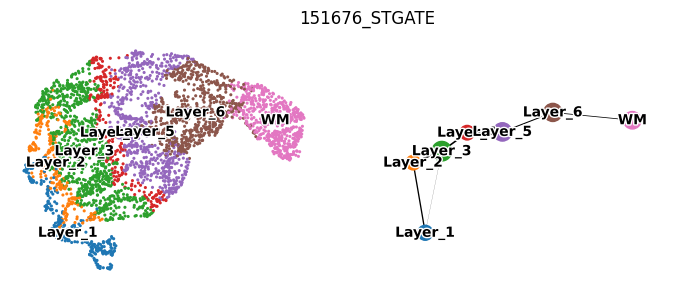

: 

In [ ]:
plt.rcParams["figure.figsize"] = (4,3)
sc.pl.paga_compare(used_adata, legend_fontsize=10, frameon=False, size=20,
                   title=section_id+'_STGATE', legend_fontoutline=2, show=False)